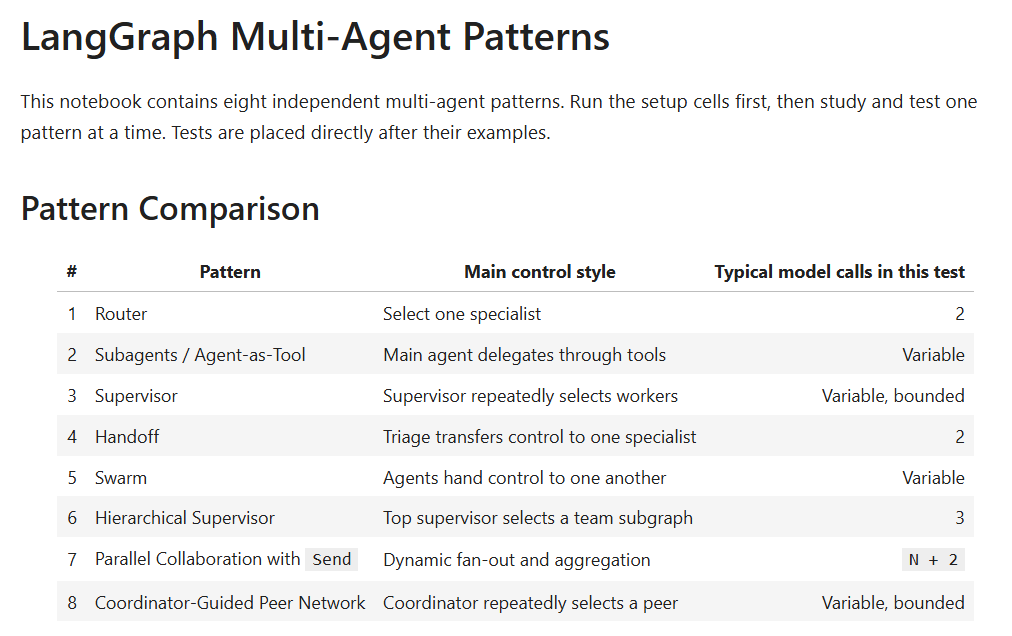

In [1]:
#ALL Import Statments 

import os
from typing import (
    TypedDict,
    Literal,
    Annotated,
)

import operator

from dotenv import load_dotenv
from pydantic import BaseModel

from langchain_openai import ChatOpenAI
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
)
from langchain_core.tools import tool
from langchain.agents import create_agent

from langgraph.graph import (
    StateGraph,
    START,
    END,
    MessagesState,
)
from langgraph.types import (
    Command,
    Send,
)
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

c:\Mine\AI\Full Stack Gen AI  BootCamp (KrishNaik)\Practicals\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
load_dotenv()
# OPENROUTER_API_KEY = os.getenv("OPENROUTER_API_KEY")

True

In [4]:
model = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
  
)



In [24]:
def show_graph(compiled_graph):
    """Print the generated graph as Mermaid text."""
    print(compiled_graph.get_graph().draw_mermaid())

## 1. Router Multi Agent
- This is Partial Agentic System Not Fully MultiAgentic system.
- Router Based LLM workflow with Specialized LLM Nodes.
- Here Router Node has Model which internally finds right Agent(Here actually it is Node) for user Query.
- Execution of Different AGent (Here Node) is made by ConditionalEdge.

**So This Is called Partial Agent**

**State and Routing Scehma**

In [45]:
class RouterDecision(BaseModel):
    route: Literal[ "technical",
        "billing",
        "general",]

In [46]:
router_model=model.with_structured_output(RouterDecision)

In [47]:
router_model.invoke("I have refund issue with my last purchase. Can you help me?")

RouterDecision(route='billing')

In [48]:
class RouterState(TypedDict):
    query:str
    route:str
    response:str

In [49]:
def router_node(state:RouterState):
    decision=router_model.invoke(
              f"""
Route the following user query to exactly one specialist.

Available specialists:
- technical
- billing
- general
User query: {state['query']}"""
    )
    return{
        "route":decision.route,
        
    }

In [50]:
def technical_agent(state:RouterState):
    response=model.invoke(
        f"""You are a technical support specialist.
        Answer the following user query in a helpful and concise manner.
        User query: {state['query']}"""
    )
    return{
        "response":response.content
    }

In [51]:
def billing_Agent(state:RouterState):
    response=model.invoke(
        f"""You are a billing support specialist.
        Answer the following user query in a helpful and concise manner.
        User query: {state['query']}"""
    )
    return{
        "response":response.content
    }

In [52]:
def general_agent(state:RouterState):
    response=model.invoke(
        f"""You are a general support specialist.
        Answer the following user query in a helpful and concise manner.
        User query: {state['query']}"""
    )
    return{
        "response":response.content
    }

In [53]:
def router_to_Specialist(state:RouterState):
    return state['route']

In [72]:
def build_router_multi_agent():
    builder = StateGraph(RouterState)
    
    builder.add_node(
        "router",
        router_node,
    )

    builder.add_node(
        "technical",
        technical_agent,
    )

    builder.add_node(
        "billing",
        billing_Agent,
    )

    builder.add_node(
        "general",
        general_agent,
    )
    builder.add_edge(START, "router")
    builder.add_conditional_edges(
        "router",
        router_to_Specialist,
        {
            "technical": "technical",
            "billing": "billing",
            "general": "general"
        }
    )
    builder.add_edge("technical", END)
    builder.add_edge("billing", END)
    builder.add_edge("general", END)   

    return builder.compile()

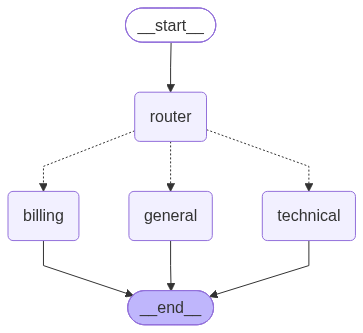

In [74]:
build_router_multi_agent()

In [73]:
router_graph = build_router_multi_agent()
show_graph(router_graph)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	router(router)
	technical(technical)
	billing(billing)
	general(general)
	__end__([<p>__end__</p>]):::last
	__start__ --> router;
	router -.-> billing;
	router -.-> general;
	router -.-> technical;
	billing --> __end__;
	general --> __end__;
	technical --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



***Test The Graph***

In [79]:
def run_routerbased_MultiAgent(inputquery:str):
     graph = (build_router_multi_agent())

     result = graph.invoke(
           {
            "query":inputquery,
            "route": "",
            "response": "",
        }
     )
     print(
        "Selected Agent:",
        result["route"],
    )
     print(
        "\nResponse:\n",
        result["response"],
    )
     return result

In [80]:
router_result = run_routerbased_MultiAgent("My subscription payment was charged twice.")


Selected Agent: billing

Response:
 I'm sorry for the inconvenience. Please provide your account details or the transaction dates so I can review the charges and assist you with a refund if needed.


In [81]:
router_result = run_routerbased_MultiAgent("I have Issue connecting to Network.")

Selected Agent: technical

Response:
 To help resolve your network connection issue, please try the following steps:

1. **Check Physical Connections:** Ensure all cables (Ethernet, modem, router) are securely connected.
2. **Restart Devices:** Power off your modem, router, and computer. Wait 30 seconds, then turn them back on.
3. **Check Wi-Fi Settings:** If using Wi-Fi, make sure you are connected to the correct network and the password is correct.
4. **Run Network Troubleshooter:** On Windows, go to Settings > Network & Internet > Status > Network troubleshooter.
5. **Check IP Settings:** Ensure your device is set to obtain an IP address automatically.
6. **Update Network Drivers:** Make sure your network adapter drivers are up to date.
7. **Check for Outages:** Contact your Internet Service Provider to see if there is an outage in your area.

If the problem persists, please provide more details about your device and network setup.


In [83]:
router_result = run_routerbased_MultiAgent("What is RAG")

Selected Agent: technical

Response:
 RAG stands for Retrieval-Augmented Generation. It is a technique in natural language processing that combines a retrieval system with a generative model. The system first retrieves relevant documents or information from a large database and then uses a generative model (like GPT) to produce a more accurate and context-aware response based on the retrieved data. This approach improves the quality and relevance of generated answers, especially for complex or specific queries.


## 2. Agent As Tool\ Subagents
- Agents are created using predefined Class (Create_agent) from langchain.
- Create_Agent is ReAct Agent.
- Agents are invoked from Tools (or) Converted to Tools
- Tools are called from LLM.

**Note:**
1. LLM itself does Tools Selection No Conditional Edges
2. All Tools are Registerd On CoOrdinator Agent (Which is Again Create_Agent) that chooses the respective agent through LLM.

User → Main Agent → Specialist Tools → Main Agent → Final Answer


In [85]:
# Imports
from langchain.agents import create_agent

**Create 3 Different Agents**
1. Math Agent
2. Research Agent
3. Writer Agent


In [90]:
math_agent=create_agent(
    model=model,
    tools=[],
    system_prompt="You are a math expert. Solve Calculations Correctly for User Query",
    name="math_agent"
)

In [91]:
research_agent=create_agent(
    model=model,
    tools=[],
    system_prompt="You are a research expert.Provide accurate and factual information for user query.",
    name="research_agent"
)

In [92]:
writer_agent=create_agent(
    model=model,
    tools=[],
    system_prompt="You are a writer expert. Answer the user query correctly and concisely.",
    name="writer_agent"
)

In [93]:
def get_last_message_content(result,):

    return (
        result["messages"][-1].content
    )

**Generate Tools And Invoke Created Agents**

In [95]:
@tool
def Math_agent(query:str)->str:
    """
    Delegate a math task to the math specialist.
    """
    result=math_agent.invoke(
        {
        "messages":[
            {
            "role":"user",
            "content":query
            }
        ]
        }
     )
    return get_last_message_content(result)

In [96]:
@tool
def Research_agent(query:str)->str:
    """
    Delegate a research task to the research specialist.
    """
    result=research_agent.invoke(
        {
            "messages": [
                {
                    "role": "user",
                    "content": query
                }
            ]
        }
    )
    return get_last_message_content(result)

In [98]:
@tool
def Writer_Agent(query:str)->str:
    """
    Delegate a writing task to the writing specialist.
    """
    result=writer_agent.invoke(
        {
            "messages":[
                {
                    "role":"user",
                    "content":query
                }
            ]
        }
    )
    return get_last_message_content(result)

**CoOrdinator Agent**
1. It is Just a CoOrdinator Agent acts like Supervisor But Not Supervisor AGent.

***Note:***
- Will See Actual Difference in next example (Supervisor Multi-Agent)

In [ ]:
Main_Agent=create_agent(
    model=model,
    tools=[Math_agent,Research_agent,Writer_Agent],
    system_prompt="You are a multi-agent coordinator." \
    " You will receive user queries and decide which specialist agent "
    "(math, research, or writing) is best suited to handle the query." \
    " Delegate the task to the appropriate agent and return their response.",
    name="MainAgent"
)

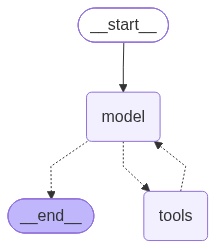

In [102]:
Main_Agent

In [104]:
def run_mainAgent():
    result=Main_Agent.invoke(
        {
            "messages":[
                {
                    "role":"user",
                    "content": (
                            "Explain RAG briefly, calculate "
                            "25 * 16, and present the answer "
                            "in a clean professional format."
                        ),
                }
            ]
        }
    )
    print(
        result["messages"][-1].content
    )

    return result


In [109]:
subagent_result=run_mainAgent()

RAG (Retrieval-Augmented Generation) is a technique in natural language processing that combines pre-trained language models with an external knowledge retrieval system. It retrieves relevant documents from a large external corpus and uses that information to generate more accurate and contextually informed responses, enhancing the model's ability to provide up-to-date and factually grounded answers.

Regarding the calculation:
25 multiplied by 16 equals 400.

Presented professionally:
25 × 16 = 400


In [111]:
run_mainAgent()

RAG (Retrieval-Augmented Generation) is a technique in natural language processing that combines retrieval-based methods with generative models. It retrieves relevant information from an external knowledge base and uses it to generate more accurate and contextually informed responses, enhancing the quality and factual accuracy of the output.

Calculation:
25 * 16 = 400

The answer is presented in a clean and professional format as requested.


{'messages': [HumanMessage(content='Explain RAG briefly, calculate 25 * 16, and present the answer in a clean professional format.', additional_kwargs={}, response_metadata={}, id='4ecc9aa0-0f61-4cc9-81a3-b85fb14d5d10'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 160, 'total_tokens': 213, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_3b4b4d3f1b', 'id': 'chatcmpl-EUR1pa3uVe49LDuZyOX76FgRDONXz', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, name='Main_Agent', id='lc_run--01a0fb4b-d147-7623-84a9-2da750f0b753-0', tool_calls=[{'name': 'Research_agent', 'args': {'query': 'Explain RAG briefly'}, 'id': 'call_S99zGQeSb5D

In [110]:
subagent_result["messages"][-1].content

"RAG (Retrieval-Augmented Generation) is a technique in natural language processing that combines pre-trained language models with an external knowledge retrieval system. It retrieves relevant documents from a large external corpus and uses that information to generate more accurate and contextually informed responses, enhancing the model's ability to provide up-to-date and factually grounded answers.\n\nRegarding the calculation:\n25 multiplied by 16 equals 400.\n\nPresented professionally:\n25 × 16 = 400"

## 3. Supervisor Multi-Agent
1. Supervisor Itself has capability (or) Intelligence to choose the next agent.
                                (OR)
   Supervisor repeatedly selects the next worker,reviews accumulated work and finishes when enough work is
   available. Limit can be imposed to avoid endless loop.
2. This Kind of Agentic System can be called as Deep Agent.
3. Here No Tool is created, supervisor itself is a agent that identify the next worker dynamically.
4. This Architecture is an perfect example for Fully Autonomous Agent

**Real-world example:** A project manager assigns research, calculation, and writing tasks one at a time, then creates the final training note.

**Flow:** 
Supervisor → Worker → Supervisor → Another Worker → Finish

***Example flow***
For “Explain RAG, calculate 25 × 16, and present the answer professionally,” the supervisor could assign research, then math, then writing. After reviewing those results, it chooses Finish, which creates the final response.


**State And Supervisor Schema**

In [5]:
class SupervisorDecision(BaseModel):
    next_agent:Literal["researchagent","mathagent","writeragent","Finish"]
    instruction:str

In [51]:
class SupervisorState(TypedDict):
    next_agent:str
    instruction:str
    task:str
    finalAnswer :str
    supervisorTurns:int
    worker_outputs:Annotated[
    list[str],
    operator.add
    ]

In [52]:
supervisor_router=model.with_structured_output(SupervisorDecision)

In [53]:
supervisor_router.invoke(
    "What is Langgrapgh")

SupervisorDecision(next_agent='researchagent', instruction="The term 'Langgrapgh' appears to be a misspelling or a term that is not widely recognized. Please research and provide information on what 'Langgrapgh' might refer to, or clarify if it is a typo for a known term such as 'Langgraph' or 'LangGraph'.")

**Lets Create Supervisor and Worker Nodes**

In [54]:
def supervisorNode(state:SupervisorState,):

    supervisor_turns= state.get("supervisorTurns", 0)+1 # Here if SupervisorTurns not present it sets 0 otherwise increaments it by 1

    completed_work = "\n\n".join(
        state.get(
            "worker_outputs",
            [],
        )
    )

    if supervisor_turns >5 and completed_work: 
        return {"next_agent":"Finish", "instruction":("You have completed the task. "
        "Please provide the final answer."),"supervisorTurns":supervisor_turns}
    
    decision=supervisor_router.invoke(
        f"""You are a supervisor managing three workers:

        - research_agent
        - math_agent
        - writer_agent

 Original task:
    {state["task"]}

    Work completed so far:
    {completed_work or "No worker has completed any work yet."}
    Choose the next worker.

Rules:
- Use research_agent for research/explanation.
- Use math_agent for calculations.
- Use writer_agent when a polished final presentation is useful.
- If enough work is complete, choose FINISH.
- Do not repeatedly call the same worker unless required.

Return:
- next_agent
- instruction for that worker
"""
    )

    return {
        "next_agent":decision.next_agent,
        "instruction":decision.instruction,
        "supervisorTurns":supervisor_turns
    }

**Create All Individual Worker Nodes**

In [ ]:
def reasearch_worker(state: SupervisorState):

    response=model.invoke(
        f"""You are a research expert. Provide accurate and factual information for the following task.
        
     Original Task:{state['task']}
     Supervisor Instruction:{state['instruction']}
     Perform only the research/explanation part."""
        )
    return {
        # "worker_outputs":state.get("worker_outputs",[])+[response]
            "worker_outputs": [
            "RESEARCH WORKER:\n"
            + response.content]
    }

In [56]:
def math_worker(state:SupervisorState):
    response=model.invoke(
        f"""You are a math expert. Solve calculations correctly for the following task.
        Orginal Task:{state['task']}
        Supervisor Instruction:{state['instruction']}

        Perform only the calculation/reasoning part.
        """
    )
    return {
        "worker_outputs": [
            "MATH WORKER:\n"
            + response.content]
    }

In [57]:
def writer_worker(state:SupervisorState):

    previous_work = "\n\n".join(
        state.get(
            "worker_outputs",
            [],
        )
    )
     
    response=model.invoke(
        f"""You are a writer expert. Answer the user query correctly and concisely.
        Original Task:{state['task']}
        Supervisor Instruction:{state['instruction']}
        Available previous work:{previous_work}

        Perform only the writing/presentation part.
        """
    )
    return {
        "worker_outputs": [
            "WRITER WORKER:\n"
            + response.content]
    }

In [70]:
def supervisor_finish(
    state: SupervisorState,
):

    completed_work = "\n\n".join(
        state["worker_outputs"]
    )

    response = model.invoke(
        f"""
You are the supervisor.

Create the final answer for the user.

Original task:
{state["task"]}

Worker outputs:
{completed_work}
"""
    )

    return {
        "finalAnswer":
        response.content
    }

In [71]:
def supervisor_route(
    state: SupervisorState,
):

    return state["next_agent"]

**Build Graph**

In [72]:
def build_Supervisor_Graph():
    builder = StateGraph(SupervisorState)

    builder.add_node(
        "supervisor",
        supervisorNode,
    )

    builder.add_node(
        "researchagent",
        reasearch_worker,
    )

    builder.add_node(
        "mathagent",
        math_worker,
    )

    builder.add_node(
        "writeragent",
        writer_worker,
    )

    builder.add_node(
        "Finish",
        supervisor_finish,
    )

    builder.add_edge(START, "supervisor")

    builder.add_conditional_edges(
        "supervisor",
        supervisor_route,
        {
            "researchagent": "researchagent",
            "mathagent": "mathagent",
            "writeragent": "writeragent",
            "Finish": "Finish"
        }
    )

    builder.add_edge("researchagent", "supervisor")
    builder.add_edge("mathagent", "supervisor")
    builder.add_edge("writeragent", "supervisor")
    builder.add_edge("Finish", END)

    return builder.compile()

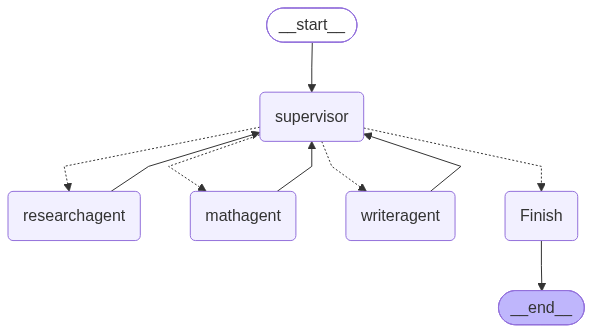

In [73]:
build_Supervisor_Graph()

**Generated Graph Flow**

In [74]:
supervisor_graph = build_Supervisor_Graph()
show_graph(supervisor_graph)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	supervisor(supervisor)
	researchagent(researchagent)
	mathagent(mathagent)
	writeragent(writeragent)
	Finish(Finish)
	__end__([<p>__end__</p>]):::last
	__start__ --> supervisor;
	mathagent --> supervisor;
	researchagent --> supervisor;
	supervisor -.-> Finish;
	supervisor -.-> mathagent;
	supervisor -.-> researchagent;
	supervisor -.-> writeragent;
	writeragent --> supervisor;
	Finish --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



**Test** 

In [75]:
def Test_Supervisor_Agent():
    print("Testing the Supervisor Graph with a sample task...")

    graph = build_Supervisor_Graph()

    result=graph.invoke(
        {
            "task": (
                "Explain RAG briefly, calculate 25 * 16, "
                "and present the answer in a clean professional format."
            ),
            "next_agent": "",
            "instruction": "",
            "finalAnswer": "",
            "supervisorTurns": 0,
            "worker_outputs": [],
        },
          config={
            "recursion_limit": 20
        },
    )   

    print("\nFinal Answer:\n", result["finalAnswer"])
    return result

In [76]:
Test_Supervisor_Agent()

Testing the Supervisor Graph with a sample task...

Final Answer:
 **Retrieval-Augmented Generation (RAG)**

Retrieval-Augmented Generation (RAG) is a natural language processing approach that combines retrieval-based methods with generative models. It first retrieves relevant information from an external knowledge source and then uses this information to guide the generation of responses. This hybrid method improves accuracy and relevance, especially for open-domain questions or tasks requiring up-to-date knowledge beyond the model’s training data.

---

**Calculation**

\[
25 \times 16 = 400
\]

**Final Result:** 400


{'next_agent': 'Finish',
 'instruction': 'The research_agent has provided a clear explanation of RAG, the math_agent has correctly calculated 25 * 16, and the writer_agent has presented the information in a clean, professional format. The task is complete.',
 'task': 'Explain RAG briefly, calculate 25 * 16, and present the answer in a clean professional format.',
 'finalAnswer': '**Retrieval-Augmented Generation (RAG)**\n\nRetrieval-Augmented Generation (RAG) is a natural language processing approach that combines retrieval-based methods with generative models. It first retrieves relevant information from an external knowledge source and then uses this information to guide the generation of responses. This hybrid method improves accuracy and relevance, especially for open-domain questions or tasks requiring up-to-date knowledge beyond the model’s training data.\n\n---\n\n**Calculation**\n\n\\[\n25 \\times 16 = 400\n\\]\n\n**Final Result:** 400',
 'supervisorTurns': 4,
 'worker_outputs'

## Supervisor Multi-Agent summary

**This graph takes a user task, has a supervisor decide which specialist should work on it, and repeats that process until the supervisor chooses to finish.**

**Components**
- SupervisorDecision defines the supervisor’s allowed choices: researchagent, mathagent, writeragent, or Finish. It also includes an instruction for the selected worker.

- SupervisorState holds the task, the next agent and its instruction, a supervisor-turn counter, and worker_outputs. The operator.add reducer accumulates each worker’s output in that list.

- supervisorNode reviews the original task and accumulated outputs, then asks the structured-output model to choose the next worker or finish. If the turn count is over five and there is already work, it forces the graph to finish

***The workers each call the model with a different role:***

- reasearch_worker handles explanations or research.
- math_worker handles calculations.
- writer_worker uses the prior worker outputs to prepare a polished presentation.

Each returns its result in worker_outputs.

- supervisor_finish combines the accumulated worker results and asks the model to produce a final answer.

- build_Supervisor_Graph wires the flow: start → supervisor → chosen worker → supervisor again. The Finish node runs once selected, then the graph ends.


